In [1]:
import numpy as np 
import pandas as pd

import plotly.express as px 
import plotly.graph_objects as go
import plotly.io as pio
pio.templates

import seaborn as sns 
import matplotlib.pyplot as plt 
%matplotlib inline 

In [2]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()

X = housing.data 
y = housing.target 

import pandas as pd
df = pd.DataFrame(X, columns=housing.feature_names)
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  


In [3]:
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target 

compression_opts = dict(method='zip', archive_name='out.csv')  
df.to_csv('out.zip', index=False, compression=compression_opts)

In [4]:
print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [5]:
print(df.shape) 

(20640, 9)


In [6]:
print(df.info)

<bound method DataFrame.info of        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       

In [7]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [ ]:
# EDA

In [8]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

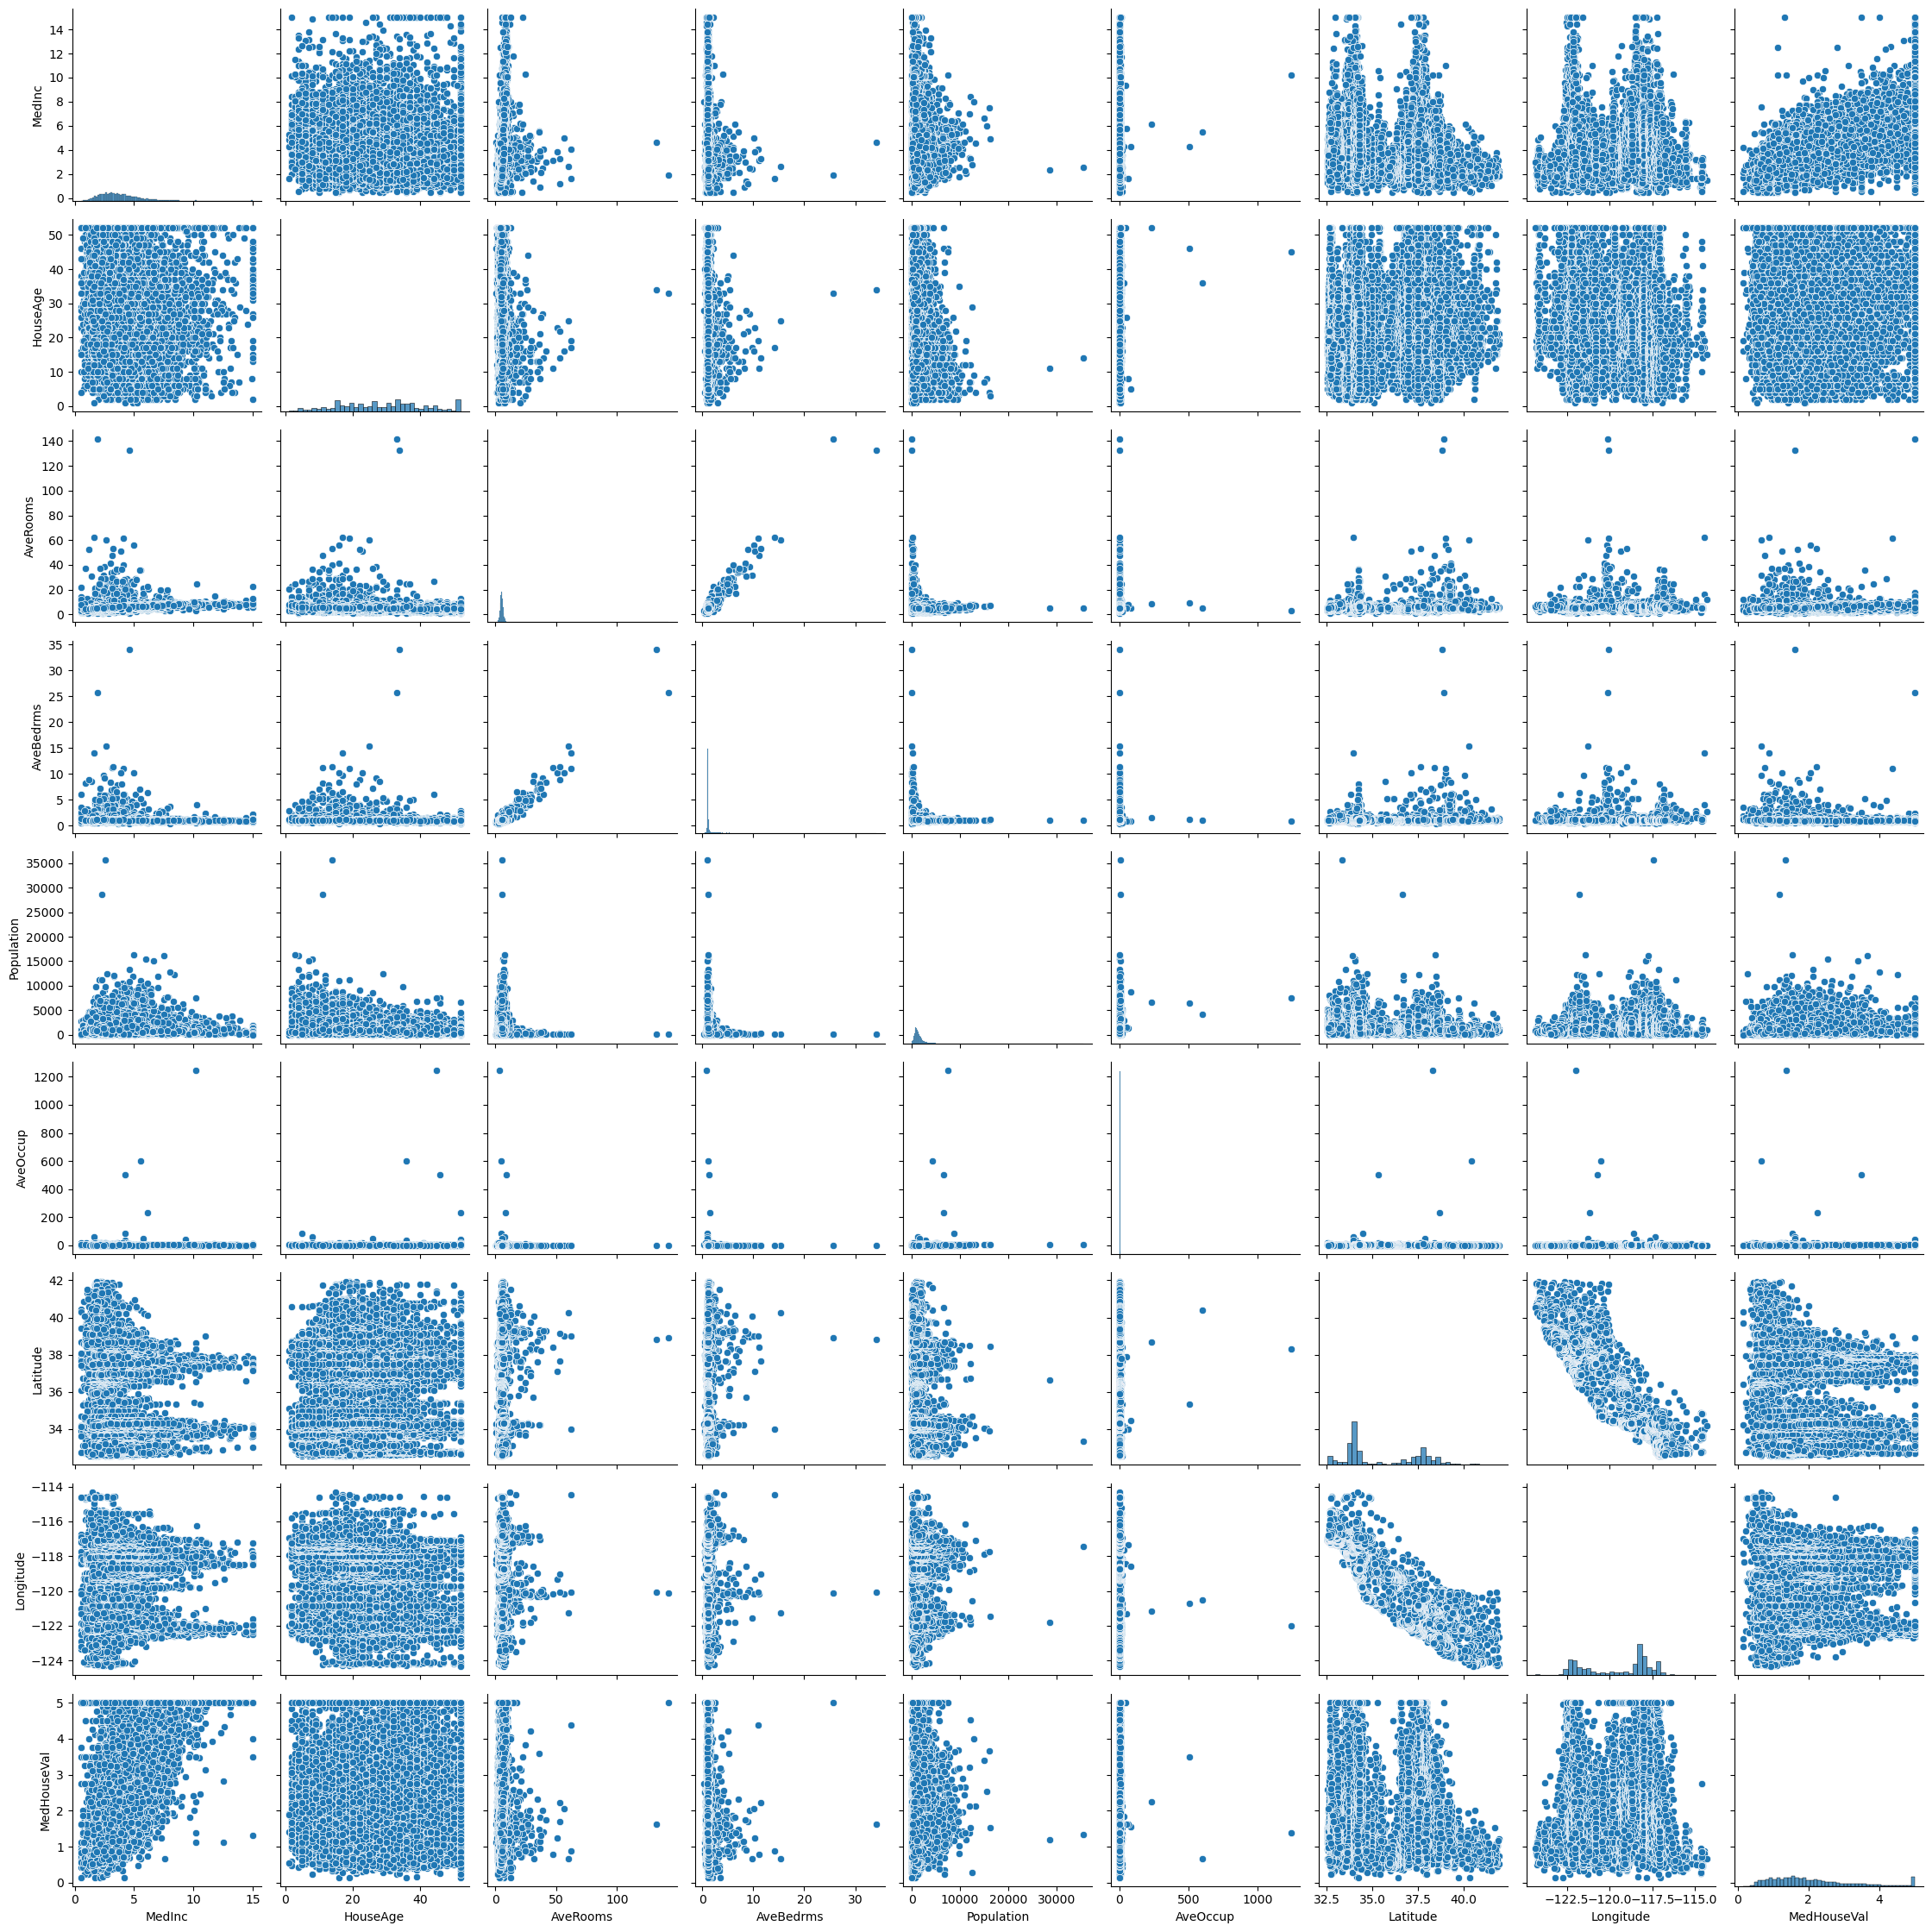

In [9]:
sns.pairplot(df, height=2.5)
plt.tight_layout()

C:\Users\Acer_Nitro\AppData\Local\Temp\ipykernel_12364\1028463333.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['AveRooms']);


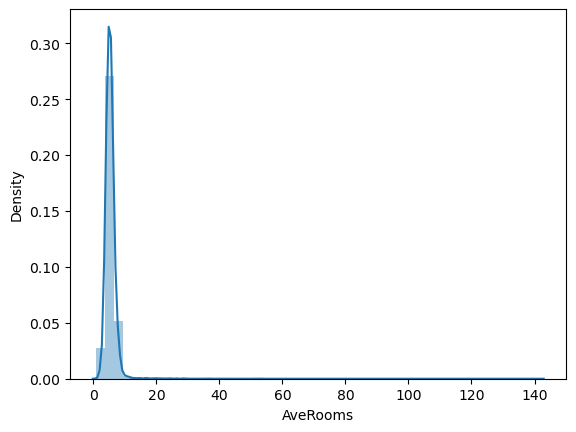

In [10]:
sns.distplot(df['AveRooms']);

In [11]:
print("Skewness: %f" % df['AveRooms'].skew())
print("Kurtosis: %f" % df['AveRooms'].kurt())

Skewness: 20.697869
Kurtosis: 879.353264


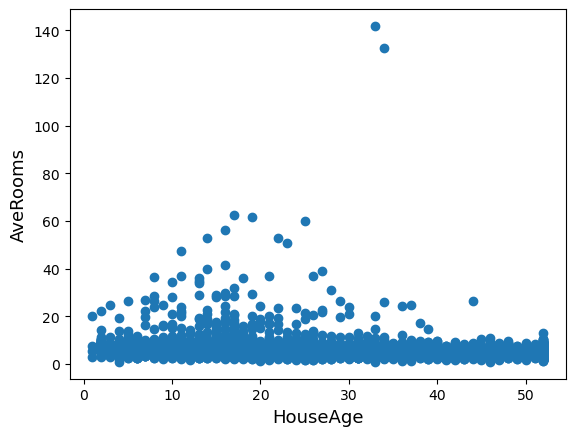

In [12]:
fig, ax = plt.subplots()
ax.scatter(x = df['HouseAge'], y = df['AveRooms'])
plt.ylabel('AveRooms', fontsize=13)
plt.xlabel('HouseAge', fontsize=13)
plt.show()

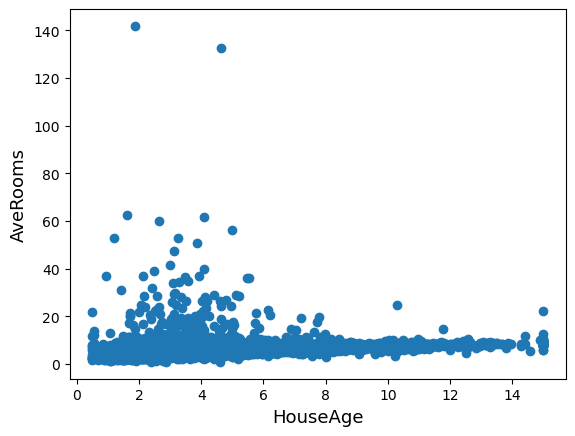

In [13]:
fig, ax = plt.subplots()
ax.scatter(x = df['MedInc'], y = df['AveRooms'])
plt.ylabel('AveRooms', fontsize=13)
plt.xlabel('HouseAge', fontsize=13)
plt.show()


 mu = 2.07 and sigma = 1.15



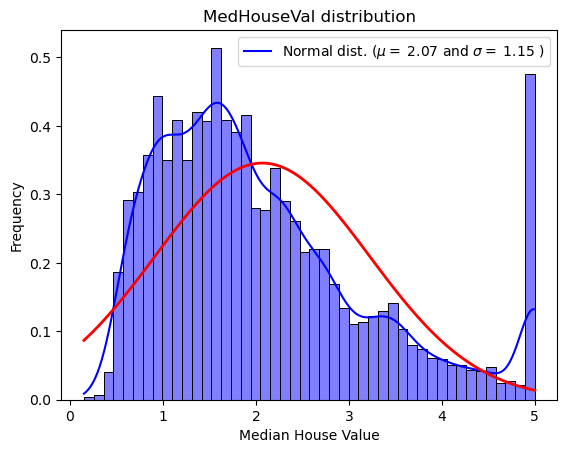

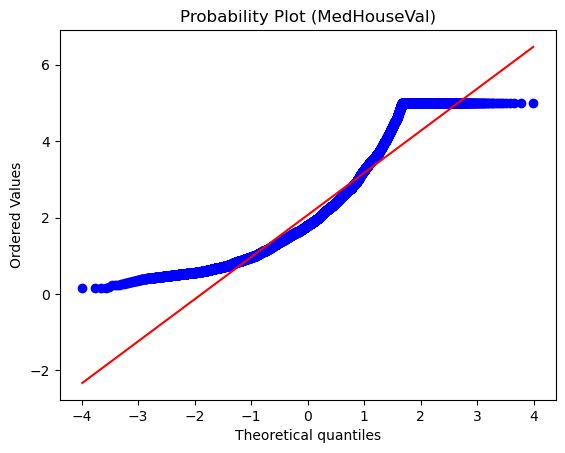

In [14]:
from scipy import stats
from scipy.stats import norm, skew 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.histplot(df['MedHouseVal'], kde=True, stat='density', color='blue')

(mu, sigma) = norm.fit(df['MedHouseVal'])
print('\n mu = {:.2f} and sigma = {:.2f}\n'.format(mu, sigma))

x = np.linspace(df['MedHouseVal'].min(), df['MedHouseVal'].max(), 100)
plt.plot(x, norm.pdf(x, mu, sigma), color='red', lw=2)

plt.legend(['Normal dist. ($\mu=$ {:.2f} and $\sigma=$ {:.2f} )'.format(mu, sigma)], loc='best')
plt.ylabel('Frequency')
plt.xlabel('Median House Value')
plt.title('MedHouseVal distribution')

fig = plt.figure()
res = stats.probplot(df['MedHouseVal'], plot=plt)
plt.title('Probability Plot (MedHouseVal)')
plt.show()


 mu = 1.06 and sigma = 0.36



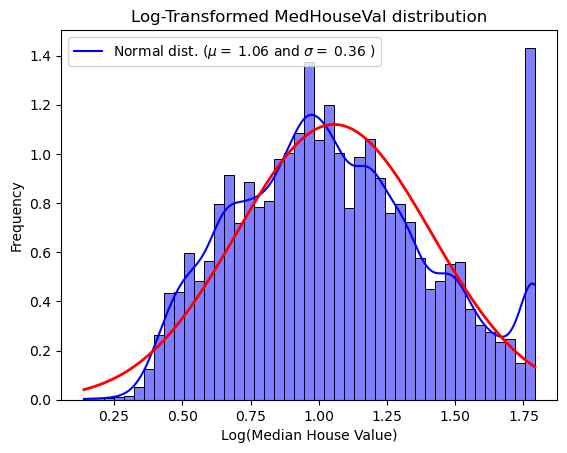

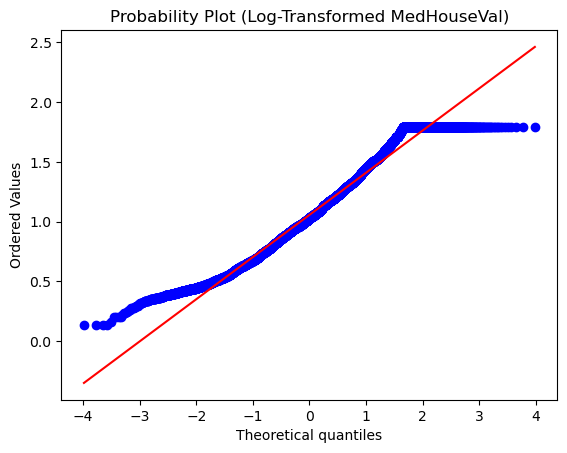

In [15]:
df["MedHouseVal"] = np.log1p(df["MedHouseVal"])

sns.histplot(df['MedHouseVal'], kde=True, stat='density', color='blue')

(mu, sigma) = norm.fit(df['MedHouseVal'])
print('\n mu = {:.2f} and sigma = {:.2f}\n'.format(mu, sigma))

x = np.linspace(df['MedHouseVal'].min(), df['MedHouseVal'].max(), 100)
plt.plot(x, norm.pdf(x, mu, sigma), color='red', lw=2)

plt.legend(['Normal dist. ($\mu=$ {:.2f} and $\sigma=$ {:.2f} )'.format(mu, sigma)], loc='best')
plt.ylabel('Frequency')
plt.xlabel('Log(Median House Value)')
plt.title('Log-Transformed MedHouseVal distribution')

fig = plt.figure()
res = stats.probplot(df['MedHouseVal'], plot=plt)
plt.title('Probability Plot (Log-Transformed MedHouseVal)')
plt.show()

In [ ]:
# DATA CORRELATION

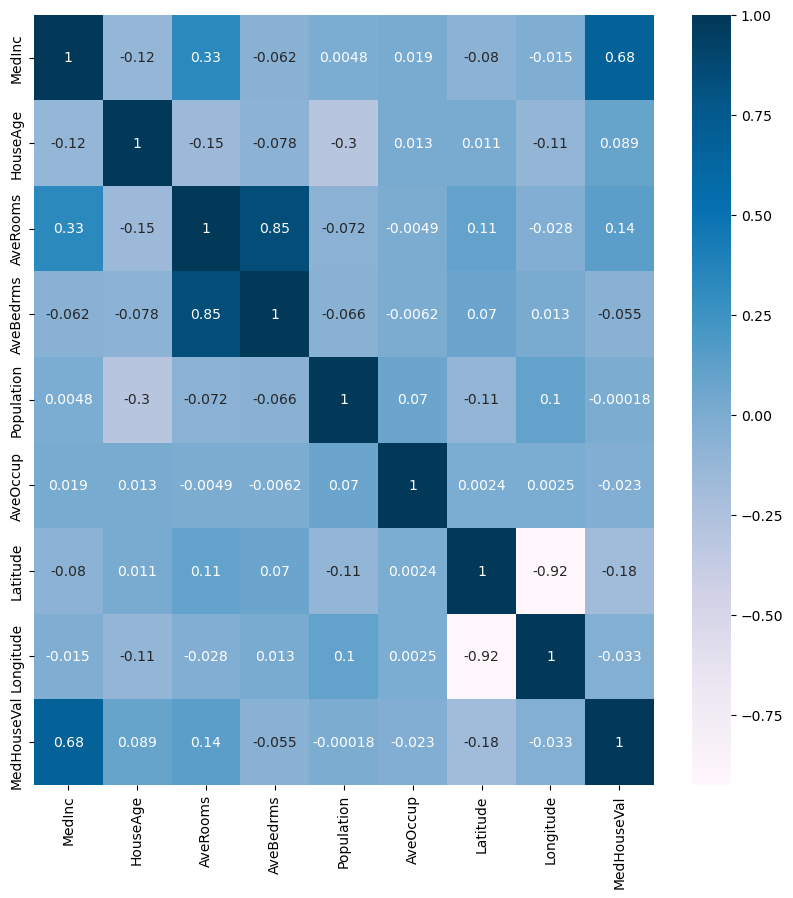

In [16]:
plt.figure(figsize=(10,10))
cor = df.corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.PuBu)
plt.show()

In [17]:
name = df.columns.tolist()

cor_target = abs(cor["AveRooms"])
relevant_features = cor_target[cor_target>0.2]

name.remove('AveRooms')

print(name)
print(len(name))

['MedInc', 'HouseAge', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']
8


In [ ]:
# MODEL BUILDING

In [18]:
from sklearn.model_selection import train_test_split 

X = df.drop("AveRooms", axis=1) 
y = df["AveRooms"]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [19]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(16512, 8)
(4128, 8)
(16512,)
(4128,)


In [20]:
from sklearn.linear_model import LinearRegression 

lr = LinearRegression() 
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
predictions = lr.predict(X_test)  

print("Actual value of the house:- ", y_test[0]) 
print("Model Predicted Value:- ", predictions[0])

Actual value of the house:-  6.984126984126984
Model Predicted Value:-  4.3677675921113615


In [22]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, predictions) 
rmse = np.sqrt(mse)
print(rmse)

0.9166808913892122
